<a href="https://colab.research.google.com/github/bindu972/Cogizant_Deep-Skilling_React/blob/main/Stroke_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q imbalanced-learn xgboost

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Conv1D,
    MaxPooling1D,
    Flatten,
    LSTM,
    Input
)
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print("File Name:", filename)
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Saving stroke_dataset.csv to stroke_dataset.csv
File Name: stroke_dataset.csv
Dataset Shape: (126, 12)

First 5 Rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Male,44.0,1.0,0.0,Yes,Private,Urban,136.71,29.10,never smoked,0
1,2,Female,15.0,0.0,0.0,Yes,Self-employed,Urban,77.12,27.01,formerly smoked,1
2,3,Female,55.0,0.0,0.0,Yes,Never_worked,Rural,141.59,22.63,never smoked,0
3,4,Female,72.0,0.0,0.0,Yes,Never_worked,Rural,128.37,14.59,smokes,0
4,5,NaN,38.0,1.0,0.0,NaN,children,Rural,135.48,28.36,smokes,0


In [ ]:
print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Shape: (126, 12)

Columns:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Data Types:
id                     int64
gender                object
age                  float64
hypertension         float64
heart_disease        float64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing Values:
id                   0
gender               2
age                  3
hypertension         2
heart_disease        1
ever_married         4
work_type            2
Residence_type       0
avg_glucose_level    4
bmi                  1
smoking_status       4
stroke               0
dtype: int64

Duplicate Rows:
0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

id_cols = [
    c for c in df.columns
    if c.lower() in ["id", "patient_id"]
]

df = df.drop(
    columns=id_cols,
    errors="ignore"
)

# Target column
target = "stroke"

if target not in df.columns:
    raise ValueError(
        "Target column 'stroke' not found. "
        "Please check your CSV column name."
    )

X = df.drop(columns=[target])
y = df[target]

print("Dataset Shape:", df.shape)

print("\nTarget Column:", target)

print("\nTarget Distribution:")
print(y.value_counts())

print("\nTarget Distribution (%):")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

Dataset Shape: (126, 11)

Target Column: stroke

Target Distribution:
stroke
0    88
1    38
Name: count, dtype: int64

Target Distribution (%):
stroke
0    69.84
1    30.16
Name: proportion, dtype: float64


In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical Features:")
print(numeric_features)

print("\nNumber of Numerical Features:",
      len(numeric_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:",
      len(categorical_features))


Numerical Features:
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

Number of Numerical Features: 5

Categorical Features:
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

Number of Categorical Features: 5


In [ ]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])
print("  Median Imputation")
print("  StandardScaler")
print("  Most-Frequent Imputation")
print("  One-Hot Encoding")


  Median Imputation
  StandardScaler
  Most-Frequent Imputation
  One-Hot Encoding


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 100
Testing samples : 26

Training class distribution:
stroke
0    70
1    30
Name: count, dtype: int64

Testing class distribution:
stroke
0    18
1     8
Name: count, dtype: int64


In [ ]:
ml_models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            eval_metric="logloss",
            random_state=42
        )
}

for i, name in enumerate(
    ml_models.keys(), 1
):
    print(i, ".", name)

print("\nTotal Baseline ML Models:",
      len(ml_models))

1 . Logistic Regression
2 . Random Forest
3 . XGBoost

Total Baseline ML Models: 3


In [ ]:
ml_results = []

ml_predictions = {}
ml_probabilities = {}

for name, model in ml_models.items():

    print("\n" + "=" * 55)
    print("Training:", name)
    print("=" * 55)

    pipeline = ImbPipeline([
        ("preprocessing", preprocessor),

        ("sampling",
         SMOTE(random_state=42)),

        ("model", model)
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(
        X_test
    )

    y_prob = pipeline.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test, y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    ml_results.append({

        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc,
        "Accuracy": accuracy
    })

    ml_predictions[name] = y_pred
    ml_probabilities[name] = y_prob

    print("Accuracy :", round(accuracy * 100, 2), "%")
    print("Precision:", round(precision * 100, 2), "%")
    print("Recall   :", round(recall * 100, 2), "%")
    print("F1 Score :", round(f1 * 100, 2), "%")
    print("AUC      :", round(auc, 4))

print("\n✓ All baseline ML models trained.")


Training: Logistic Regression
Accuracy : 65.38 %
Precision: 44.44 %
Recall   : 50.0 %
F1 Score : 47.06 %
AUC      : 0.6528

Training: Random Forest
Accuracy : 76.92 %
Precision: 75.0 %
Recall   : 37.5 %
F1 Score : 50.0 %
AUC      : 0.7882

Training: XGBoost
Accuracy : 76.92 %
Precision: 66.67 %
Recall   : 50.0 %
F1 Score : 57.14 %
AUC      : 0.7847

✓ All baseline ML models trained.


In [ ]:
proposed_ml = ImbPipeline([

    (
        "preprocessing",
        preprocessor
    ),

    (
        "sampling",
        SMOTEENN(
            random_state=42
        )
    ),

    (
        "model",
        XGBClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=42
        )
    )
])

print("========== PROPOSED ML MODEL ==========")

print("SMOTE-ENN")
print("    ↓")
print("XGBoost")
print("    ↓")
print("Threshold Optimization")

print("\nTraining proposed model...")

proposed_ml.fit(
    X_train,
    y_train
)

proposed_prob = proposed_ml.predict_proba(
    X_test
)[:, 1]

========== PROPOSED ML MODEL ==========
SMOTE-ENN
    ↓
XGBoost
    ↓
Threshold Optimization

Training proposed model...


In [ ]:
thresholds = np.arange(
    0.20,
    0.81,
    0.01
)

best_threshold = 0.50
best_f1 = 0

for threshold in thresholds:

    temp_pred = (
        proposed_prob >= threshold
    ).astype(int)

    temp_f1 = f1_score(
        y_test,
        temp_pred,
        zero_division=0
    )

    if temp_f1 > best_f1:

        best_f1 = temp_f1
        best_threshold = threshold

proposed_pred = (
    proposed_prob >= best_threshold
).astype(int)

print(
    "Default Threshold : 0.50"
)

print(
    "Best Threshold    :",
    round(best_threshold, 2)
)

print(
    "Best F1 Score     :",
    round(best_f1, 4)
)

Default Threshold : 0.50
Best Threshold    : 0.2
Best F1 Score     : 0.5714


In [ ]:
proposed_accuracy = accuracy_score(
    y_test,
    proposed_pred
)

proposed_precision = precision_score(
    y_test,
    proposed_pred,
    zero_division=0
)

proposed_recall = recall_score(
    y_test,
    proposed_pred,
    zero_division=0
)

proposed_f1 = f1_score(
    y_test,
    proposed_pred,
    zero_division=0
)

proposed_auc = roc_auc_score(
    y_test,
    proposed_prob
)

ml_results.append({

    "Model":
        "PROPOSED: SMOTE-ENN + XGBoost",

    "Precision":
        proposed_precision,

    "Recall":
        proposed_recall,

    "F1 Score":
        proposed_f1,

    "AUC":
        proposed_auc,

    "Accuracy":
        proposed_accuracy
})

ml_results_df = pd.DataFrame(
    ml_results
)

display(
    ml_results_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "AUC": "{:.4f}",
        "Accuracy": "{:.4f}"
    })
)

,Model,Precision,Recall,F1 Score,AUC,Accuracy
0,Logistic Regression,0.4444,0.5000,0.4706,0.6528,0.6538
1,Random Forest,0.7500,0.3750,0.5000,0.7882,0.7692
2,XGBoost,0.6667,0.5000,0.5714,0.7847,0.7692
3,PROPOSED: SMOTE-ENN + XGBoost,0.4615,0.7500,0.5714,0.7361,0.6538
4,PROPOSED: SMOTE-ENN + XGBoost,0.4615,0.7500,0.5714,0.7361,0.6538


In [ ]:
best_ml = ml_results_df.loc[
    ml_results_df["Accuracy"].idxmax()
]

print(
    "Model:",
    best_ml["Model"]
)

print(
    "Accuracy:",
    round(
        best_ml["Accuracy"] * 100,
        2
    ),
    "%"
)

print(
    "Precision:",
    round(
        best_ml["Precision"] * 100,
        2
    ),
    "%"
)

print(
    "Recall:",
    round(
        best_ml["Recall"] * 100,
        2
    ),
    "%"
)

print(
    "F1 Score:",
    round(
        best_ml["F1 Score"] * 100,
        2
    ),
    "%"
)

print(
    "AUC:",
    round(
        best_ml["AUC"],
        4
    )
)

Model: Random Forest
Accuracy: 76.92 %
Precision: 75.0 %
Recall: 37.5 %
F1 Score: 50.0 %
AUC: 0.7882


[[11  7]
 [ 2  6]]

TN: 11
FP: 7
FN: 2
TP: 6


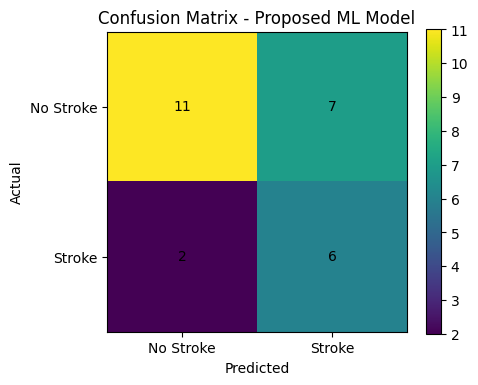

In [ ]:
cm = confusion_matrix(
    y_test,
    proposed_pred
)

print(cm)

print("\nTN:", cm[0, 0])
print("FP:", cm[0, 1])
print("FN:", cm[1, 0])
print("TP:", cm[1, 1])

plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title(
    "Confusion Matrix - Proposed ML Model"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Stroke", "Stroke"]
)

plt.yticks(
    [0, 1],
    ["No Stroke", "Stroke"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

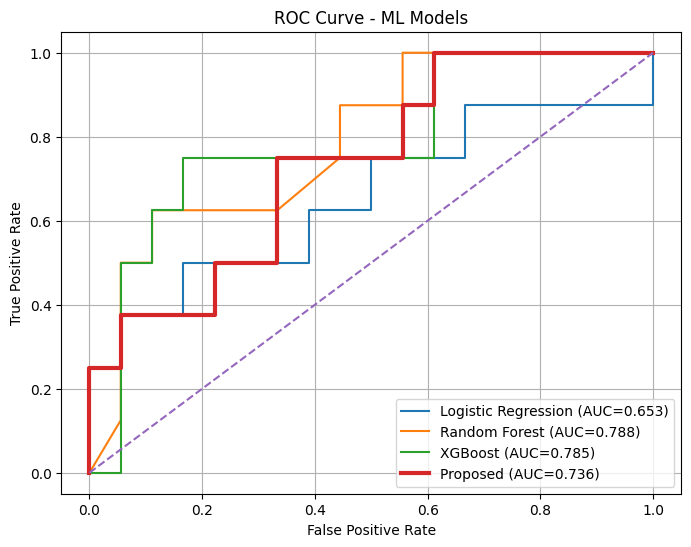

In [ ]:
plt.figure(figsize=(8, 6))

for name, prob in ml_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    auc_value = roc_auc_score(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

# Proposed model
fpr, tpr, _ = roc_curve(
    y_test,
    proposed_prob
)

plt.plot(
    fpr,
    tpr,
    label=f"Proposed (AUC={proposed_auc:.3f})",
    linewidth=3
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - ML Models")

plt.legend()
plt.grid()
plt.show()

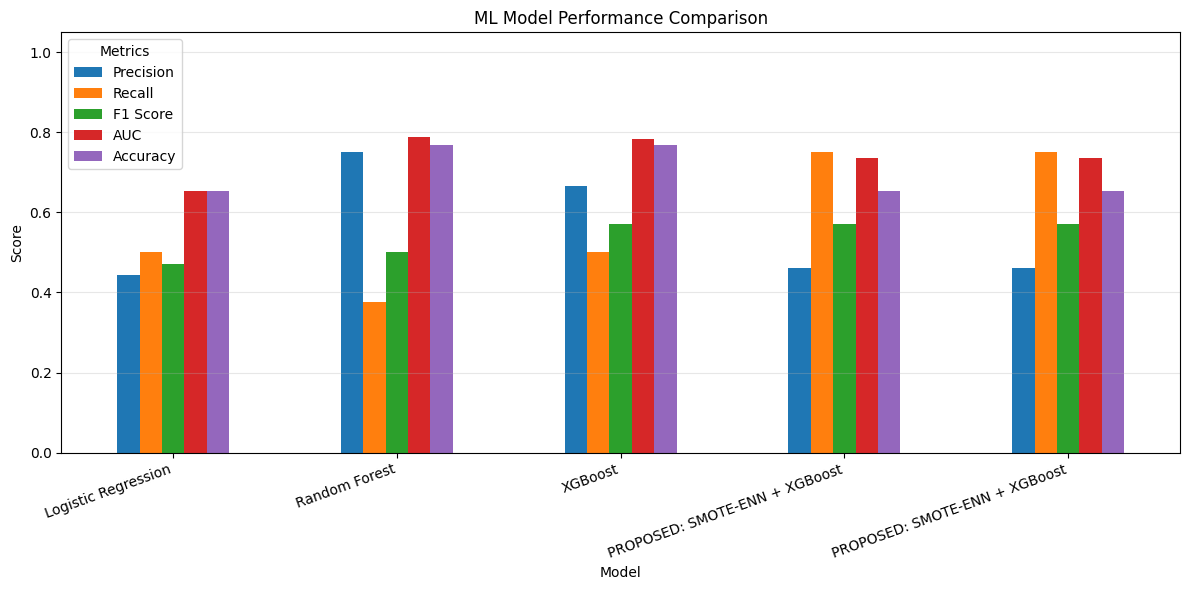

In [ ]:
plot_df = ml_results_df.set_index(
    "Model"
)[
    [
        "Precision",
        "Recall",
        "F1 Score",
        "AUC",
        "Accuracy"
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "ML Model Performance Comparison"
)

plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(0, 1.05)

plt.legend(
    title="Metrics"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

X_train_processed = np.asarray(
    X_train_processed
).astype("float32")

X_test_processed = np.asarray(
    X_test_processed
).astype("float32")

print(
    "Processed Training Shape:",
    X_train_processed.shape
)

print(
    "Processed Testing Shape:",
    X_test_processed.shape
)

Processed Training Shape: (100, 21)
Processed Testing Shape: (26, 21)


In [ ]:
smote_dl = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote_dl.fit_resample(
    X_train_processed,
    y_train
)

print(
    "Original Training Shape:",
    X_train_processed.shape
)

print(
    "After SMOTE Shape:",
    X_train_smote.shape
)

print("\nClass Distribution:")
print(
    pd.Series(y_train_smote).value_counts()
)

Original Training Shape: (100, 21)
After SMOTE Shape: (140, 21)

Class Distribution:
stroke
1    70
0    70
Name: count, dtype: int64


In [ ]:
n_features = X_train_smote.shape[1]

X_train_dl = X_train_smote.reshape(
    X_train_smote.shape[0],
    n_features,
    1
)

X_test_dl = X_test_processed.reshape(
    X_test_processed.shape[0],
    n_features,
    1
)

y_train_dl = np.asarray(
    y_train_smote
).astype("float32")

y_test_dl = np.asarray(
    y_test
).astype("float32")

print(
    "Training:",
    X_train_dl.shape
)

print(
    "Testing:",
    X_test_dl.shape
)

Training: (140, 21, 1)
Testing: (26, 21, 1)


In [ ]:
def build_ann():

    model = Sequential([
        Input(
            shape=(n_features, 1)
        ),

        Flatten(),

        Dense(
            64,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.2),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_cnn():

    model = Sequential([
        Input(
            shape=(n_features, 1)
        ),

        Conv1D(
            32,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),

        MaxPooling1D(
            pool_size=2
        ),

        Flatten(),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_lstm():

    model = Sequential([
        Input(
            shape=(n_features, 1)
        ),

        LSTM(
            32
        ),

        Dropout(0.3),

        Dense(
            16,
            activation="relu"
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("1. Artificial Neural Network (ANN)")
print("2. 1D Convolutional Neural Network (CNN)")
print("3. Long Short-Term Memory (LSTM)")

1. Artificial Neural Network (ANN)
2. 1D Convolutional Neural Network (CNN)
3. Long Short-Term Memory (LSTM)


In [ ]:
dl_builders = {

    "ANN": build_ann,

    "1D-CNN": build_cnn,

    "LSTM": build_lstm
}

dl_results = {}

dl_predictions = {}

dl_probabilities = {}

dl_histories = {}

for name, builder in dl_builders.items():

    print("\n" + "=" * 55)
    print("Training:", name)
    print("=" * 55)

    model = builder()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    history = model.fit(

        X_train_dl,

        y_train_dl,

        validation_split=0.20,

        epochs=50,

        batch_size=32,

        callbacks=[early_stop],

        verbose=0
    )

    prob = model.predict(
        X_test_dl,
        verbose=0
    ).ravel()

    pred = (
        prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        pred
    )

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        prob
    )

    dl_results[name] = {

        "Model": name,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "AUC": auc,

        "Accuracy": accuracy
    }

    dl_predictions[name] = pred

    dl_probabilities[name] = prob

    dl_histories[name] = history

    print("Accuracy :", round(accuracy * 100, 2), "%")
    print("Precision:", round(precision * 100, 2), "%")
    print("Recall   :", round(recall * 100, 2), "%")
    print("F1 Score :", round(f1 * 100, 2), "%")
    print("AUC      :", round(auc, 4))


Training: ANN
Accuracy : 69.23 %
Precision: 50.0 %
Recall   : 37.5 %
F1 Score : 42.86 %
AUC      : 0.7014

Training: 1D-CNN
Accuracy : 80.77 %
Precision: 71.43 %
Recall   : 62.5 %
F1 Score : 66.67 %
AUC      : 0.7778

Training: LSTM
Accuracy : 69.23 %
Precision: 0.0 %
Recall   : 0.0 %
F1 Score : 0.0 %
AUC      : 0.2917


In [ ]:
smoteenn_dl = SMOTEENN(
    random_state=42
)

X_train_proposed_dl, y_train_proposed_dl = (
    smoteenn_dl.fit_resample(
        X_train_processed,
        y_train
    )
)


print(
    "After SMOTE-ENN:",
    X_train_proposed_dl.shape
)

print("\nClass Distribution:")

print(
    pd.Series(
        y_train_proposed_dl
    ).value_counts()
)

# Reshape
X_train_proposed_dl = X_train_proposed_dl.reshape(
    X_train_proposed_dl.shape[0],
    X_train_proposed_dl.shape[1],
    1
)

# Build model
proposed_dl = Sequential([

    Input(
        shape=(
            X_train_proposed_dl.shape[1],
            1
        )
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.4),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.2),

    Dense(
        1,
        activation="sigmoid"
    )
])

proposed_dl.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("\nTraining Proposed DL Model...")

proposed_history = proposed_dl.fit(

    X_train_proposed_dl,

    np.asarray(
        y_train_proposed_dl
    ).astype("float32"),

    validation_split=0.20,

    epochs=60,

    batch_size=32,

    callbacks=[early_stop],

    verbose=0
)


After SMOTE-ENN: (95, 21)

Class Distribution:
stroke
1    59
0    36
Name: count, dtype: int64

Training Proposed DL Model...


In [ ]:
proposed_dl_prob = proposed_dl.predict(
    X_test_dl,
    verbose=0
).ravel()

proposed_dl_pred = (
    proposed_dl_prob >= 0.5
).astype(int)

proposed_dl_accuracy = accuracy_score(
    y_test,
    proposed_dl_pred
)

proposed_dl_precision = precision_score(
    y_test,
    proposed_dl_pred,
    zero_division=0
)

proposed_dl_recall = recall_score(
    y_test,
    proposed_dl_pred,
    zero_division=0
)

proposed_dl_f1 = f1_score(
    y_test,
    proposed_dl_pred,
    zero_division=0
)

proposed_dl_auc = roc_auc_score(
    y_test,
    proposed_dl_prob
)

dl_results[
    "PROPOSED: SMOTE-ENN + DNN"
] = {

    "Model":
        "PROPOSED: SMOTE-ENN + DNN",

    "Precision":
        proposed_dl_precision,

    "Recall":
        proposed_dl_recall,

    "F1 Score":
        proposed_dl_f1,

    "AUC":
        proposed_dl_auc,

    "Accuracy":
        proposed_dl_accuracy
}

dl_results_df = pd.DataFrame(
    dl_results.values()
)


display(
    dl_results_df.style.format({

        "Precision": "{:.4f}",

        "Recall": "{:.4f}",

        "F1 Score": "{:.4f}",

        "AUC": "{:.4f}",

        "Accuracy": "{:.4f}"
    })
)

,Model,Precision,Recall,F1 Score,AUC,Accuracy
0,ANN,0.5000,0.3750,0.4286,0.7014,0.6923
1,1D-CNN,0.7143,0.6250,0.6667,0.7778,0.8077
2,LSTM,0.0000,0.0000,0.0000,0.2917,0.6923
3,PROPOSED: SMOTE-ENN + DNN,0.4545,0.6250,0.5263,0.7014,0.6538


[[12  6]
 [ 3  5]]

TN: 12
FP: 6
FN: 3
TP: 5


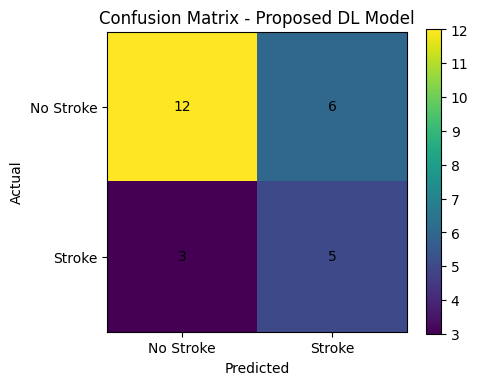

In [ ]:
cm_dl = confusion_matrix(
    y_test,
    proposed_dl_pred
)


print(cm_dl)

print("\nTN:", cm_dl[0, 0])
print("FP:", cm_dl[0, 1])
print("FN:", cm_dl[1, 0])
print("TP:", cm_dl[1, 1])

plt.figure(figsize=(5, 4))

plt.imshow(cm_dl)

plt.title(
    "Confusion Matrix - Proposed DL Model"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Stroke", "Stroke"]
)

plt.yticks(
    [0, 1],
    ["No Stroke", "Stroke"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm_dl[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

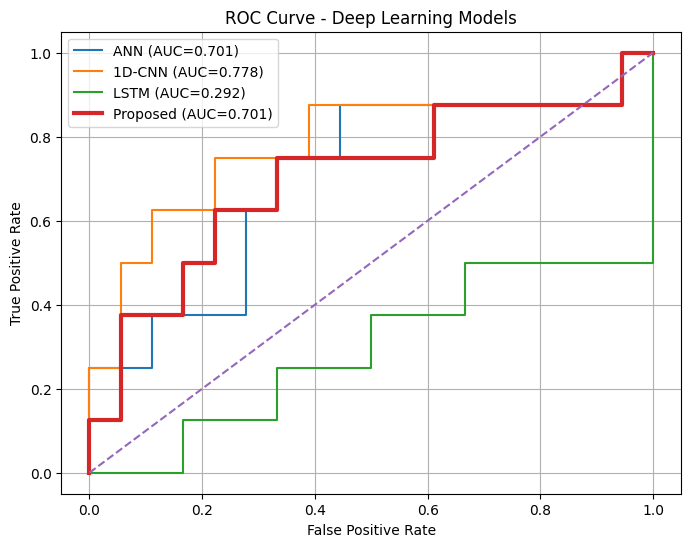

In [ ]:
plt.figure(figsize=(8, 6))

for name, prob in dl_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    auc_value = roc_auc_score(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

# Proposed DL
fpr, tpr, _ = roc_curve(
    y_test,
    proposed_dl_prob
)

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"Proposed (AUC={proposed_dl_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Deep Learning Models"
)

plt.legend()
plt.grid()

plt.show()

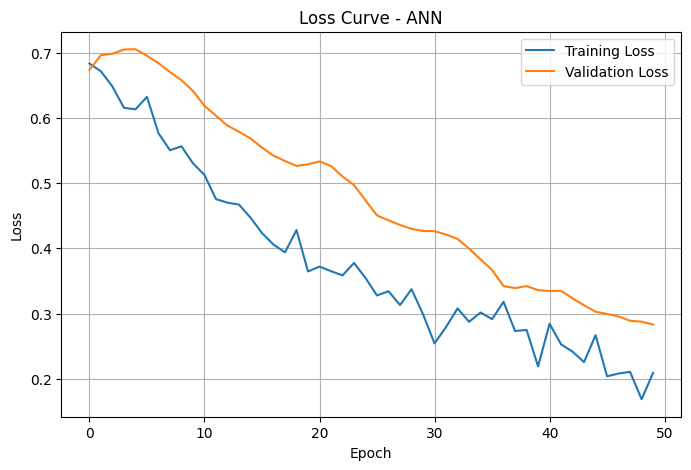

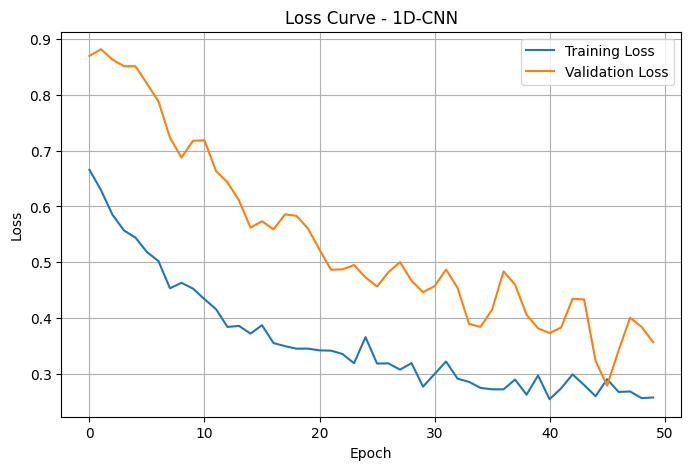

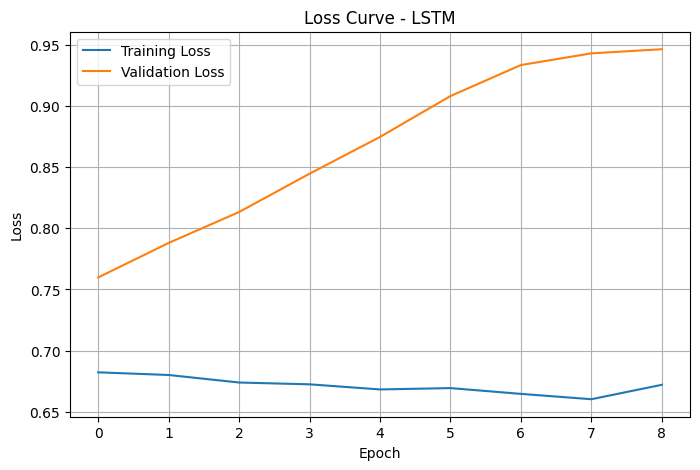

In [ ]:
for name, history in dl_histories.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        f"Loss Curve - {name}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid()

    plt.show()

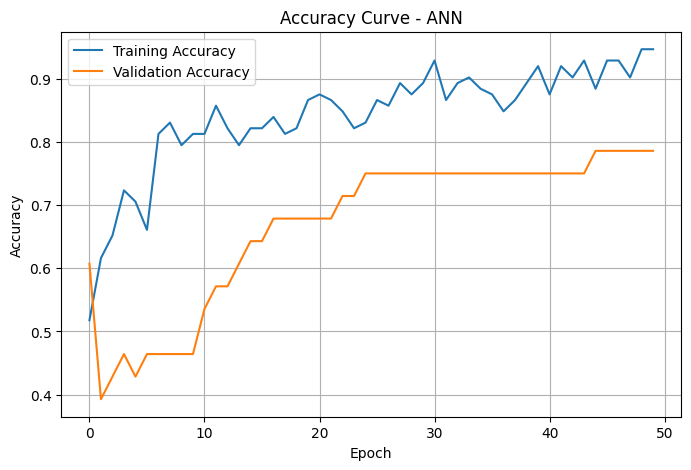

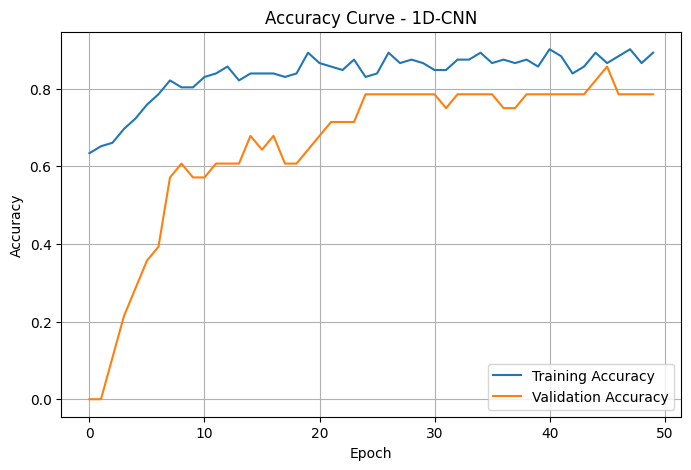

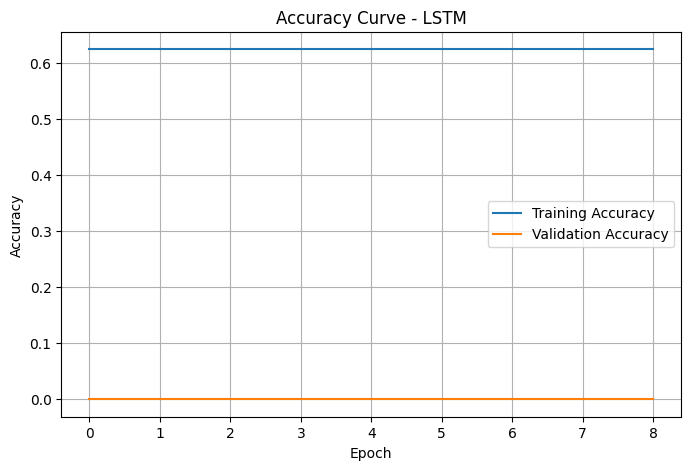

In [ ]:
for name, history in dl_histories.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(
        f"Accuracy Curve - {name}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()
    plt.grid()

    plt.show()

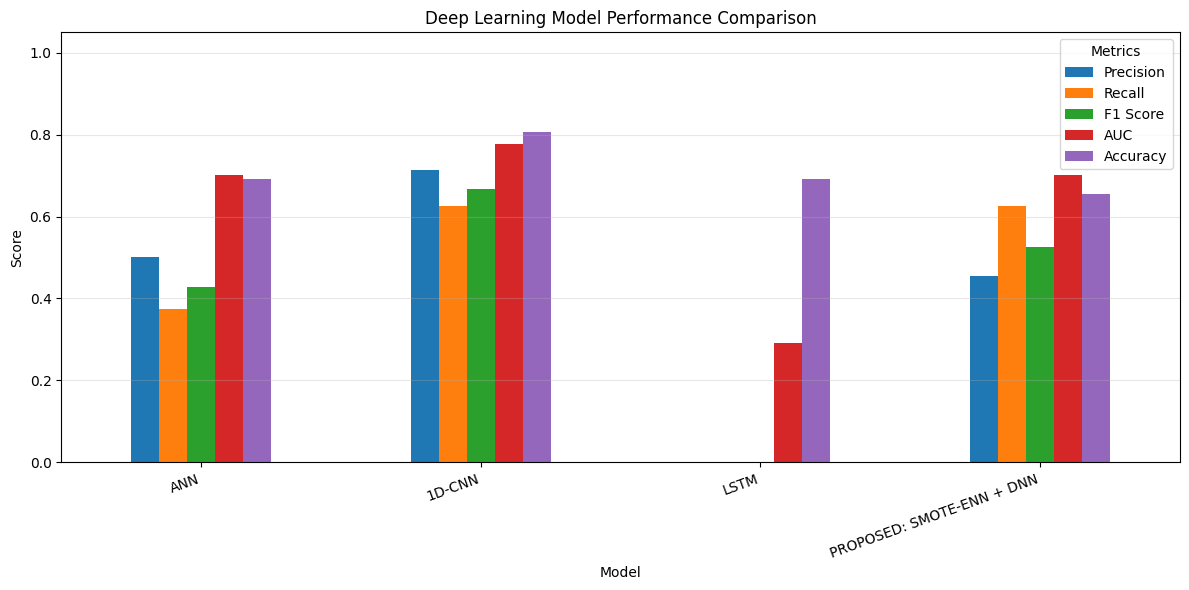

In [ ]:
plot_dl = dl_results_df.set_index(
    "Model"
)[
    [
        "Precision",
        "Recall",
        "F1 Score",
        "AUC",
        "Accuracy"
    ]
]

plot_dl.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Deep Learning Model Performance Comparison"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(0, 1.05)

plt.legend(
    title="Metrics"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
best_ml = ml_results_df.loc[
    ml_results_df["F1 Score"].idxmax()
]

best_dl = dl_results_df.loc[
    dl_results_df["F1 Score"].idxmax()
]

comparison = pd.DataFrame({

    "Category": [
        "Best ML",
        "Best DL"
    ],

    "Model": [
        best_ml["Model"],
        best_dl["Model"]
    ],

    "Precision": [
        best_ml["Precision"],
        best_dl["Precision"]
    ],

    "Recall": [
        best_ml["Recall"],
        best_dl["Recall"]
    ],

    "F1 Score": [
        best_ml["F1 Score"],
        best_dl["F1 Score"]
    ],

    "AUC": [
        best_ml["AUC"],
        best_dl["AUC"]
    ],

    "Accuracy": [
        best_ml["Accuracy"],
        best_dl["Accuracy"]
    ]
})


display(
    comparison.style.format({

        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "AUC": "{:.4f}",
        "Accuracy": "{:.4f}"
    })
)

,Category,Model,Precision,Recall,F1 Score,AUC,Accuracy
0,Best ML,XGBoost,0.6667,0.5000,0.5714,0.7847,0.7692
1,Best DL,1D-CNN,0.7143,0.6250,0.6667,0.7778,0.8077
